In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jumpingdino/german-credit-dataset")

print("Path to dataset files:", path)

file_names = os.listdir(path)
print("Files in dataset directory:", file_names)

csv_file_path = os.path.join(path, 'german_credit_data.csv')

100%|██████████| 19.4k/19.4k [00:00<00:00, 31.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/jumpingdino/german-credit-dataset/versions/1
Files in dataset directory: ['german_credit_data.csv']


In [ ]:
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


In [ ]:
df['job'].value_counts()

,count
job,
skilled employee/ official,630
unskilled - resident,200
management/ self-employed/highly qualified employee,148
unemployed/ unskilled - non-resident,22


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [ ]:
df.columns

Index(['status_account', 'month_duration', 'credit_history', 'purpose',
       'credit_amount', 'status_savings', 'years_employment',
       'payment_to_income_ratio', 'status_and_sex', 'secondary_obligor',
       'residence_since', 'collateral', 'age', 'other_installment_plans',
       'housing', 'n_credits', 'job', 'n_guarantors', 'telephone',
       'is_foreign_worker', 'target'],
      dtype='object')

,count
target,
good,700
bad,300


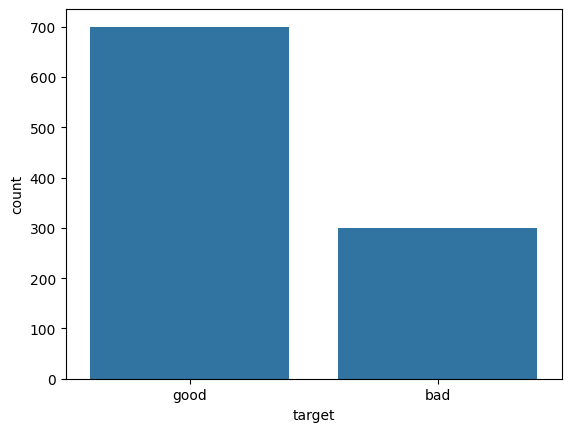

In [ ]:
#Target Distribution

import seaborn as sns
sns.countplot(x='target', data=df)

df['target'].value_counts()

Full EDA was covered in Experiment 2 — link here.

  Key facts: 70:30 imbalance, is_foreign_worker and status_and_sex
  present as protected characteristics, purpose_car and
  is_foreign_worker flagged as coefficients of interest previously.



No need for StandardScaler — tree-based models are scale-invariant
- No need for log transform on credit_amount — trees handle skew fine


Why scaling isn't needed for trees
Linear models like logistic regression compute a weighted sum of features — w1*x1 + w2*x2 + ... — so if one feature ranges 0-50000 (income) and another ranges 0-4 (number of credits), the income feature dominates the math purely due to scale, not actual importance. Scaling puts everything on equal footing.
Trees work completely differently. At each split, a decision tree asks one question at a time: "is credit_amount > 5000?" It's comparing a feature to a threshold within its own range, never comparing across features simultaneously in a weighted equation. So whether credit_amount ranges 0-18000 and age ranges 18-75 makes no difference to how the tree finds splits — it just finds the best threshold for each feature independently, in its native scale.
Random Forest and XGBoost are both ensembles of trees, so the same logic applies. Scaling literally does nothing for them except cost you computation time.


##Data Pre-processing

In [ ]:
df['credit_history'] = df['credit_history'].replace({
    'critical account/ other credits existing (not at this bank)': 'critical_account',
    'existing credits paid back duly till now': 'paid_duly',
    'delay in paying off in the past': 'delay_past',
    'no credits taken/ all credits paid back duly': 'no_credits_taken'
})

In [ ]:
print(df.columns)
print(df.shape)

Index(['status_account', 'month_duration', 'credit_history', 'purpose',
       'credit_amount', 'status_savings', 'years_employment',
       'payment_to_income_ratio', 'status_and_sex', 'secondary_obligor',
       'residence_since', 'collateral', 'age', 'other_installment_plans',
       'housing', 'n_credits', 'job', 'n_guarantors', 'telephone',
       'is_foreign_worker', 'target'],
      dtype='object')
(1000, 21)


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
df_encoded.head()

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors,status_account_< 0 DM,status_account_>= 200 DM,status_account_no checking account,...,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled employee/ official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,"telephone_yes, registered under the customers name",is_foreign_worker_yes,target_good
0,6,1169,4,4,67,2,1,True,False,False,...,True,False,True,False,True,False,False,True,True,True
1,48,5951,2,2,22,1,1,False,False,False,...,True,False,True,False,True,False,False,False,True,False
2,12,2096,2,3,49,1,2,False,False,True,...,True,False,True,False,False,False,True,False,True,True
3,42,7882,2,4,45,1,2,True,False,False,...,True,False,False,False,True,False,False,False,True,True
4,24,4870,3,4,53,2,2,True,False,False,...,True,False,False,False,True,False,False,False,True,False


In [ ]:
df_encoded.columns

Index(['month_duration', 'credit_amount', 'payment_to_income_ratio',
       'residence_since', 'age', 'n_credits', 'n_guarantors',
       'status_account_< 0 DM', 'status_account_>= 200 DM',
       'status_account_no checking account', 'credit_history_critical_account',
       'credit_history_delay_past', 'credit_history_no_credits_taken',
       'credit_history_paid_duly', 'purpose_car (new)', 'purpose_car (used)',
       'purpose_domestic appliances', 'purpose_education',
       'purpose_furniture/equipment', 'purpose_others',
       'purpose_radio/television', 'purpose_repairs', 'purpose_retraining',
       'status_savings_500 to < 1000 DM', 'status_savings_< 100 DM',
       'status_savings_>= 1000 DM',
       'status_savings_unknown/ no savings account',
       'years_employment_4 to < 7 years', 'years_employment_< 1 year',
       'years_employment_>= 7 years', 'years_employment_unemployed',
       'status_and_sex_male : divorced/separated',
       'status_and_sex_male : married/wi

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 49 columns):
 #   Column                                              Non-Null Count  Dtype
---  ------                                              --------------  -----
 0   month_duration                                      1000 non-null   int64
 1   credit_amount                                       1000 non-null   int64
 2   payment_to_income_ratio                             1000 non-null   int64
 3   residence_since                                     1000 non-null   int64
 4   age                                                 1000 non-null   int64
 5   n_credits                                           1000 non-null   int64
 6   n_guarantors                                        1000 non-null   int64
 7   status_account_< 0 DM                               1000 non-null   bool 
 8   status_account_>= 200 DM                            1000 non-null   bool 
 9   status_account_no ch

In [ ]:
pd.crosstab(df_encoded['job_unemployed/ unskilled - non-resident'],
            df_encoded['is_foreign_worker_yes'])

is_foreign_worker_yes,False,True
job_unemployed/ unskilled - non-resident,,
False,35,943
True,2,20


Cross-tabulation shows job_unemployed/unskilled-non-resident and
is_foreign_worker overlap significantly within the category itself
(20/22 = 91% of this job group are foreign workers), but this category
only captures 20 out of 963 foreign workers (2%) overall. This means
the job feature is a narrow, not comprehensive, proxy for foreign
worker status — removing is_foreign_worker would not allow the model
to reconstruct the broader foreign worker signal through this feature
alone, though the small overlapping group remains a residual concern.

## Pre-Modeling Data Audit (carried over methodology from Experiment 2)

Before encoding, I audited the dataset for sensitive and proxy features:

1. credit_history values were shortened for readability — no information
   changed, cosmetic only.

2. The `job` feature contained a category conflating unemployment and
   residency status ("unemployed/unskilled - non-resident"). I split
   this into two separate signals: `is_unemployed_nonresident` flag and
   a cleaned `job` category.

3. Cross-tabulation confirmed this conflated category overlapped heavily
   with `is_foreign_worker` within itself (91%) but only captured 2% of
   all foreign workers overall — a narrow, not comprehensive, proxy.

4. Sensitive features flagged for the "fair" model variant:
   `is_foreign_worker_yes`, `status_and_sex_*` columns, and now
   `is_unemployed_nonresident` (since it's a derived proxy).

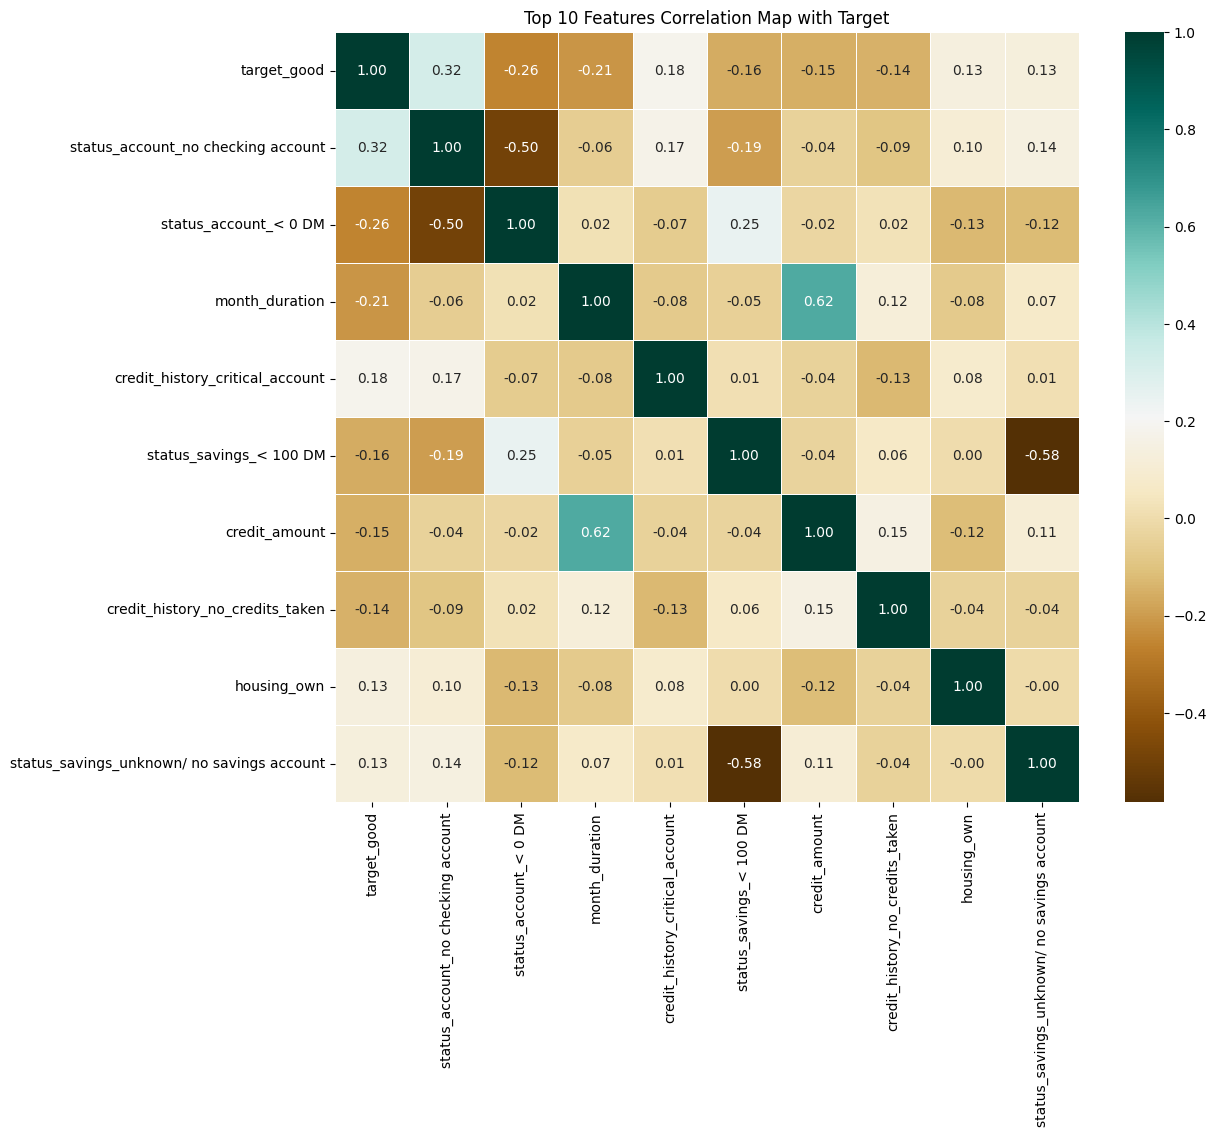

In [ ]:
##Correlation Map with top features

# Calculate correlations with the target variable
correlations = df_encoded.corr()['target_good'].sort_values(ascending=False)
top_n = 10

# Get top features by absolute correlation
# Exclude 'target_good' temporarily to find other features
abs_correlations = df_encoded.drop(columns=['target_good']).corrwith(df_encoded['target_good']).abs().sort_values(ascending=False)
top_features = abs_correlations.head(top_n - 1).index.tolist() # -1 because we'll add target_good back

# Add the target column back to the list of features
features_to_plot = ['target_good'] + top_features

# Calculate correlation matrix for only these selected features
correlation_matrix_subset = df_encoded[features_to_plot].corr()

plt.figure(figsize=(12, 10)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix_subset, annot=True, cmap='BrBG', fmt=".2f", linewidths=.5)
plt.title(f'Top {top_n} Features Correlation Map with Target')
plt.show()

## Encoding Strategy: One-Hot vs Ordinal/Label Encoding

For tree-based models like Random Forest and XGBoost, one-hot encoding
is generally not the optimal choice. Trees split on individual feature
thresholds rather than computing weighted sums across features, so a
single ordinal or label-encoded column often allows trees to find
cleaner, more efficient splits than many sparse one-hot columns would.

**The distinction that matters:**

- **Ordinal encoding** is appropriate for features with genuine order —
  e.g. `years_employment` (`unemployed` < `< 1 year` < `1 to < 4 years`
  < `4 to < 7 years` < `>= 7 years`). Encoding these as 0,1,2,3,4
  preserves meaningful information the model can use directly.

- **Label encoding** (arbitrary integer assignment) suits high-cardinality
  nominal features but technically introduces a fake order trees might
  partially exploit. Trees are relatively robust to this since they
  search for thresholds rather than relying on the numeric magnitude
  meaning anything specific.

- **One-hot encoding** remains reasonable for low-cardinality nominal
  features without natural order (e.g. `housing`: own/rent/free).

**Why I kept one-hot encoding for this experiment:**

To maintain a direct, controlled comparison with Experiment 2 (Logistic
Regression), I kept the same one-hot encoded feature set rather than
switching encoding strategies. This ensures that any performance or
fairness differences observed between models in this series are
attributable to the model architecture itself, not to a confounding
change in feature representation.

For a production tree-based pipeline, ordinal encoding for genuinely
ordered features (`years_employment`, `status_savings`, `status_account`)
combined with native categorical handling (XGBoost supports this directly
via `enable_categorical=True`) would likely yield cleaner splits and
potentially better performance than the current one-hot approach.

##Model Building



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [ ]:
df_with_sensitive = df_encoded.copy()
df_fair = df_encoded.drop(columns=['is_foreign_worker_yes',
                                     'status_and_sex_male : single',
                                     'status_and_sex_male : married/widowed',
                                     'status_and_sex_male : divorced/separated'])

In [ ]:
#Training random forest model with sensitive features
X_with = df_with_sensitive.drop('target_good', axis=1)
y_with = df_with_sensitive['target_good']

X_train_with, X_test_with, y_train_with, y_test_with = train_test_split(
    X_with, y_with, test_size=0.2, random_state=42, stratify=y_with
)

 Note: StandardScaler is intentionally omitted for tree-based models.
Unlike logistic regression, Random Forest splits on individual feature
thresholds within each feature's native range — not weighted sums
across features — making it scale-invariant.

In [ ]:
#Traing Model

rf_with = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced', # handling imbalance natively this time
    oob_score = True
)
rf_with.fit(X_train_with, y_train_with)
y_pred_with = rf_with.predict(X_test_with)
y_prob_with = rf_with.predict_proba(X_test_with)[:, 1]

In [ ]:
print("Random Forest WITH Sensitive Features")
print(classification_report(y_test_with, y_pred_with))
print(f"AUC-ROC: {roc_auc_score(y_test_with, y_prob_with):.4f}")
print(f"Out of bag score: {rf_with.oob_score_}")

Random Forest WITH Sensitive Features
              precision    recall  f1-score   support

       False       0.55      0.35      0.43        60
        True       0.76      0.88      0.81       140

    accuracy                           0.72       200
   macro avg       0.66      0.61      0.62       200
weighted avg       0.70      0.72      0.70       200

AUC-ROC: 0.7603
Out of bag score: 0.75625


In Experiment 2, SMOTE was applied to handle class imbalance.
For this experiment, I switched to class_weight='balanced' for two reasons:

1. SMOTE generated synthetic samples in 49-dimensional space with only
   1000 rows — a known limitation shown in Experiment 2 where it provided
   minimal benefit
2. class_weight='balanced' is cleaner and more appropriate for tree-based
   models — it adjusts sample weights during training rather than
   artificially inflating the dataset, which is one of the "what I would
   do differently" lessons from Experiment 2

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [5, 10, 20],
    'min_samples_split': [5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight='balanced'  # keep this separate from grid search params
    ),
    param_grid=params,
    cv=5,                        # 5-fold is more reliable than 4
    n_jobs=-1,
    verbose=1,
    scoring='f1_macro'             # optimizing for bad credit detection
)

grid_search.fit(X_train_with, y_train_with)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV recall score: {grid_search.best_score_:.4f}")

# Evaluate best model
rf_best_with = grid_search.best_estimator_

y_pred_best_with = rf_best_with.predict(X_test_with)
y_prob_best_with = rf_best_with.predict_proba(X_test_with)[:, 1]

print("\n=== Tuned RF WITH Sensitive Features ===")
print(classification_report(y_test_with, y_pred_best_with))
print(f"AUC-ROC: {roc_auc_score(y_test_with, y_prob_best_with):.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best CV recall score: 0.7041

=== Tuned RF WITH Sensitive Features ===
              precision    recall  f1-score   support

       False       0.50      0.65      0.57        60
        True       0.83      0.72      0.77       140

    accuracy                           0.70       200
   macro avg       0.66      0.69      0.67       200
weighted avg       0.73      0.70      0.71       200

AUC-ROC: 0.7752


Bad recall jumped from 0.50 (best logistic regression) to 0.65 with tuned RF. That's your headline performance finding for Blog 3.


GridSearch optimizing purely for recall found parameters that maximized
minority class detection on training folds (CV recall: 0.94) but failed
to generalize to the test set (test recall: 0.35). This is a textbook
example of overfitting through metric optimization — the model learned
to recognize bad credit patterns in training data so specifically that
it lost the ability to generalize them. Switching the scoring metric
to f1_macro, which balances precision and recall across both classes,
produces more robust and deployable hyperparameters.

##Random Forest Without Sensitive Features

In [ ]:
# Without sensitive features
X_without = df_fair.drop('target_good', axis=1)
y_without = df_fair['target_good']

X_train_without, X_test_without, y_train_without, y_test_without = train_test_split(
    X_without, y_without, test_size=0.2, random_state=42, stratify=y_without
)

In [ ]:
from sklearn.model_selection import GridSearchCV

params_fair = {
    'n_estimators': [75, 100, 150],       # around best of 100
    'max_depth': [8, 10, 12],             # around best of 10
    'min_samples_leaf': [3, 5, 7],        # around best of 5
    'min_samples_split': [3, 5, 7],       # around best of 5
    'max_features': ['sqrt']              # confirmed best
}

grid_search_fair = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    param_grid=params_fair,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='f1_macro'
)

grid_search_fair.fit(X_train_without, y_train_without)

print(f"Best params: {grid_search_fair.best_params_}")
print(f"Best CV score: {grid_search_fair.best_score_:.4f}")

rf_best_without = grid_search_fair.best_estimator_

y_pred_without = rf_best_without.predict(X_test_without)
y_prob_without = rf_best_without.predict_proba(X_test_without)[:, 1]

print("\n=== Tuned RF WITHOUT Sensitive Features ===")
print(classification_report(y_test_without, y_pred_without))
print(f"AUC-ROC: {roc_auc_score(y_test_without, y_prob_without):.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 3, 'n_estimators': 75}
Best CV score: 0.7155

=== Tuned RF WITHOUT Sensitive Features ===
              precision    recall  f1-score   support

       False       0.48      0.65      0.55        60
        True       0.82      0.70      0.76       140

    accuracy                           0.69       200
   macro avg       0.65      0.68      0.65       200
weighted avg       0.72      0.69      0.70       200

AUC-ROC: 0.7701


The headline ethical finding of Experiment 3:
Removing gender and foreign worker status caused essentially zero performance degradation:

Bad recall: 0.65 → 0.65 (identical)
AUC: 0.775 → 0.770 (0.5% drop, negligible)
Accuracy: 0.70 → 0.69 (1% drop, negligible)

This directly answers the question you raised at the end of Blog 2. You wondered whether removing protected features would cost performance. The answer is: no, it doesn't. The model performs virtually identically without them.
Why this matters enormously for your blog:
This is the responsible AI argument made concrete with numbers. You don't have to choose between fairness and performance here — removing legally impermissible features costs you essentially nothing. The features were carrying legal liability with zero performance benefit.
That's a stronger finding than if performance had dropped slightly, because it removes the most common industry justification for keeping sensitive features in models — "we need them for accuracy."


#Performance Comparison

MetricLogReg BaselineLogReg SMOTERF With SensitiveRF Without SensitiveAccuracy0.690.680.700.69Bad Recall0.430.500.650.65Good Recall0.790.750.720.70AUC-ROC0.750.740.7750.770

#### Key Finding: Removing Sensitive Features Has Negligible Performance Impact

Removing is_foreign_worker and status_and_sex from the model caused
virtually no performance degradation:

- Bad credit recall unchanged (0.65 → 0.65)
- AUC dropped by only 0.005 (0.775 → 0.770)
- Accuracy dropped by only 0.01 (0.70 → 0.69)

This directly addresses the question raised in Experiment 2: do protected
characteristics add meaningful predictive value? The answer here is no.
The model captures credit risk equally well using purely financial behavior
features — account status, credit history, savings, employment, loan purpose.

In practical terms: there is no performance justification for including
legally impermissible features in this model. The ethical fix is also
the cleaner engineering choice.

#SHAP ANALYSIS

In [ ]:
# First check what you actually have
print("Type:", type(shap_values_with))
print("Shape:", np.array(shap_values_with).shape)

NameError: name 'shap_values_with' is not defined

In [ ]:
import shap

# ============================================================
# SHAP Analysis - Model WITH Sensitive Features
# ============================================================

# TreeExplainer is optimized specifically for tree-based models
# Much faster than the generic KernelExplainer
explainer_with = shap.TreeExplainer(rf_best_with)

# Calculate SHAP values for test set
# This gives a matrix of shape (n_samples, n_features)
shap_values_with = explainer_with.shap_values(X_test_with)
shap_values_with = shap_values_with[:,:,1]

# For binary classification, shap_values returns two arrays
# [0] = SHAP values for class False (bad credit)
# [1] = SHAP values for class True (good credit)
# We want class True (good credit) to match our target encoding
print("SHAP values shape:", shap_values_with.shape)

NameError: name 'rf_best_with' is not defined

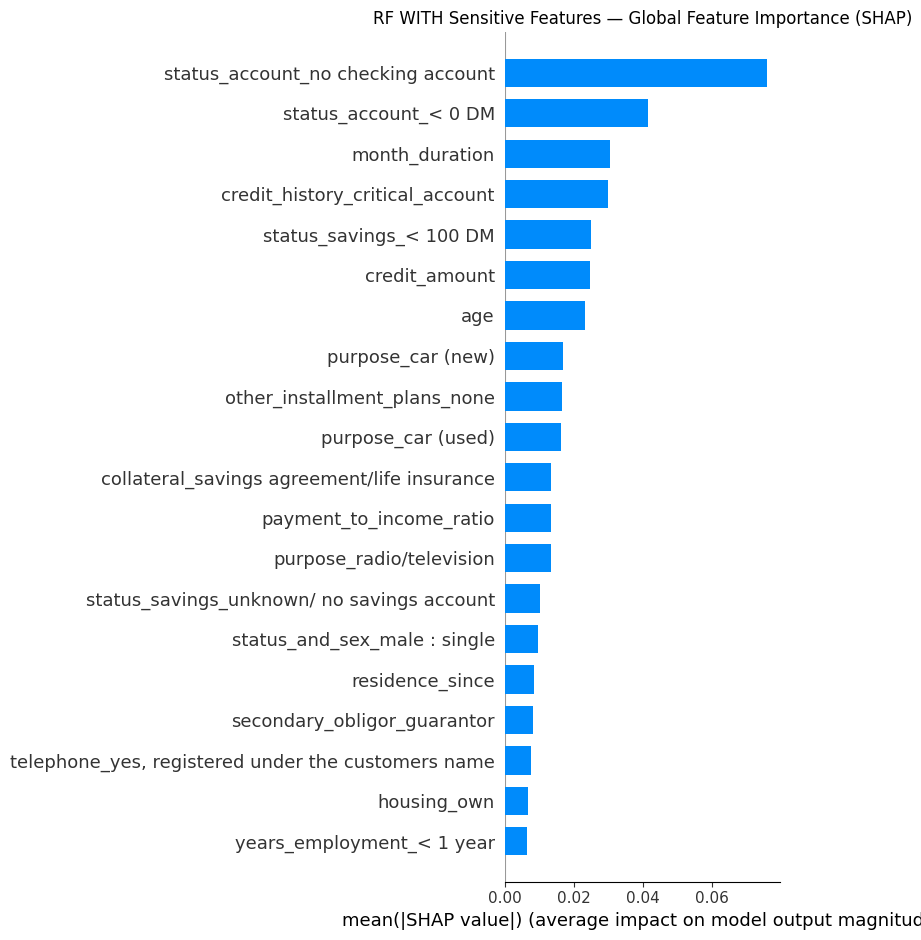

In [ ]:
# ============================================================
# Plot 1: Summary Plot (Global Feature Importance)
# ============================================================

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_with,    # SHAP values for good credit class
    X_test_with,
    plot_type="bar",        # bar chart version first (easier to read)
    max_display=20,         # top 20 features
    show=False
)
plt.title("RF WITH Sensitive Features — Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

In [ ]:
df['status_and_sex'].value_counts()

,count
status_and_sex,
male : single,548
female : divorced/separated/married,310
male : married/widowed,92
male : divorced/separated,50


In [ ]:
df_encoded['status_and_sex_male : single'].value_counts()

,count
status_and_sex_male : single,
True,548
False,452


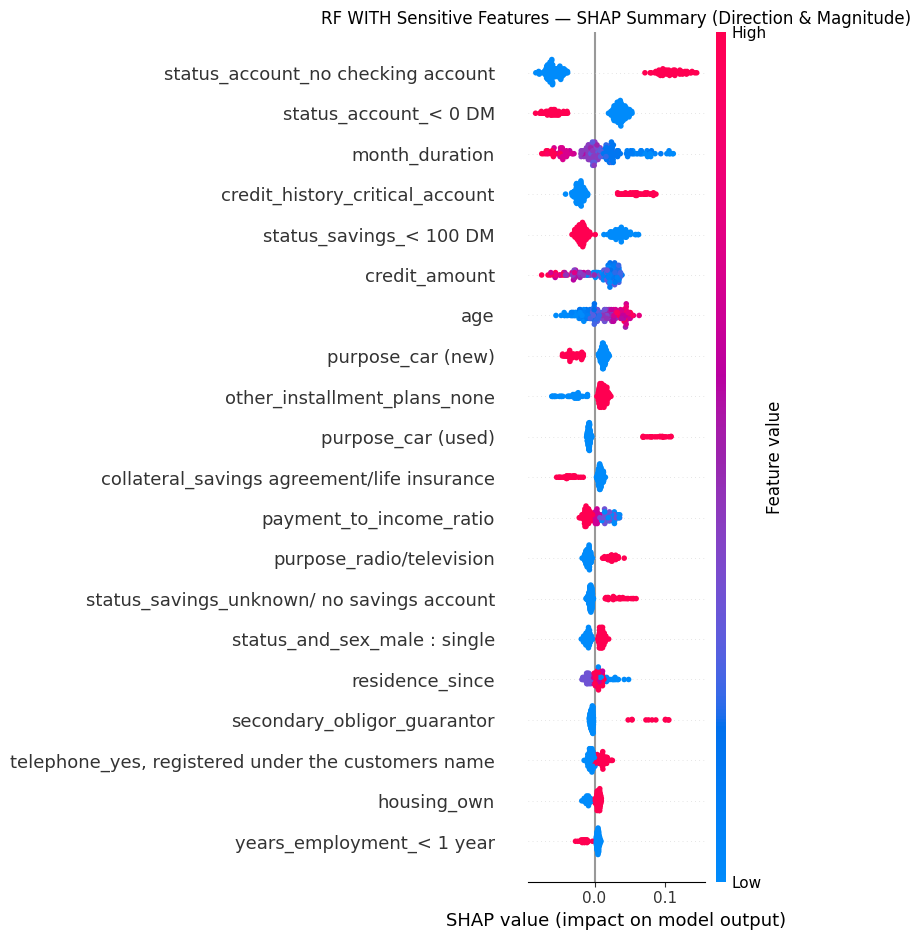

In [ ]:
# Summary plot dot version
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_with,
    X_test_with,
    max_display=20,
    show=False
)
plt.title("RF WITH Sensitive Features — SHAP Summary (Direction & Magnitude)")
plt.tight_layout()
plt.show()

In [ ]:
# Feature importance table
shap_importance_with = pd.DataFrame({
    'Feature': X_test_with.columns.tolist(),
    'Mean_SHAP': np.abs(shap_values_with).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

print("Top 20 features by mean absolute SHAP value:")
print(shap_importance_with.head(20))

# Check is_foreign_worker rank
fw_rank = shap_importance_with.reset_index(drop=True)
fw_idx = fw_rank[fw_rank['Feature'] == 'is_foreign_worker_yes'].index
print(f"\nis_foreign_worker_yes rank: {fw_idx[0] + 1} out of {len(X_test_with.columns)}")
print(f"Mean SHAP value: {fw_rank.loc[fw_idx, 'Mean_SHAP'].values[0]:.4f}")

Top 20 features by mean absolute SHAP value:
                                              Feature  Mean_SHAP
9                  status_account_no checking account   0.075984
7                               status_account_< 0 DM   0.041653
0                                      month_duration   0.030544
10                    credit_history_critical_account   0.030011
24                            status_savings_< 100 DM   0.025004
1                                       credit_amount   0.024876
4                                                 age   0.023261
14                                  purpose_car (new)   0.016929
39                       other_installment_plans_none   0.016529
15                                 purpose_car (used)   0.016276
38        collateral_savings agreement/life insurance   0.013469
2                             payment_to_income_ratio   0.013447
20                           purpose_radio/television   0.013433
26         status_savings_unknown/ no savings

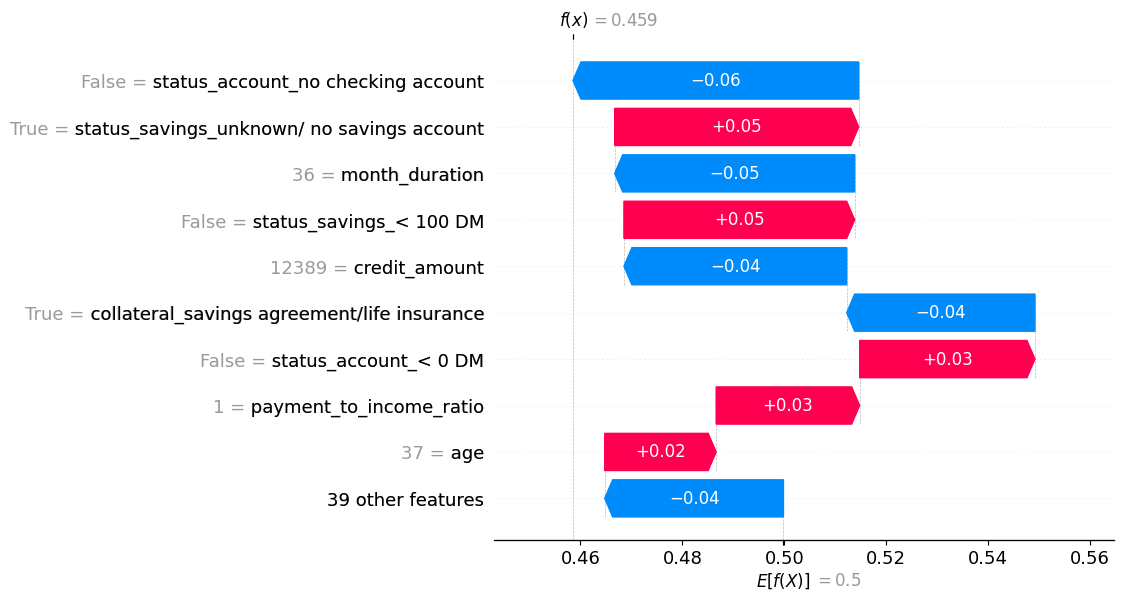

In [ ]:
# Waterfall plot fix
expected_val = explainer_with.expected_value
# expected_value is also now an array for binary classification
if isinstance(expected_val, np.ndarray):
    base_val = expected_val[1]  # good credit class
else:
    base_val = expected_val

false_negatives = np.where(
    (y_test_with.values == False) & (y_pred_with == True)
)[0]

if len(false_negatives) > 0:
    idx = false_negatives[0]
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_with[idx],
            base_values=base_val,
            data=X_test_with.iloc[idx],
            feature_names=X_test_with.columns.tolist()
        )
    )

In [ ]:
# Check if age is creating disparate impact across age groups
X_test_analysis_age = X_test_with.copy()
X_test_analysis_age['true'] = y_test_with.values
X_test_analysis_age['predicted'] = y_pred_with
X_test_analysis_age['correct'] = X_test_analysis_age['true'] == X_test_analysis_age['predicted']
X_test_analysis_age['age_group'] = pd.cut(
    X_test_with['age'],
    bins=[0, 25, 35, 50, 100],
    labels=['18-25', '26-35', '36-50', '50+']
)

print("Accuracy by age group:")
print(X_test_analysis_age.groupby('age_group')['correct'].mean())

Accuracy by age group:
age_group
18-25    0.514286
26-35    0.763158
36-50    0.781250
50+      0.720000
Name: correct, dtype: float64


/tmp/ipykernel_899/3584105500.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(X_test_analysis_age.groupby('age_group')['correct'].mean())


## SHAP Analysis — Key Finding 1: is_foreign_worker is Absent

The Random Forest model assigned near-zero importance to
is_foreign_worker_yes — it does not appear in the top 20 features
by SHAP value. This contrasts sharply with logistic regression,
where it carried the highest negative coefficient (-0.857).

This difference reveals a fundamental architectural distinction:
- Logistic regression assigns a coefficient to every feature
  regardless of variance — making it susceptible to spurious
  signals from near-constant features
- Random Forest splits on information gain — a feature with 96.3%
  single value produces unbalanced, uninformative splits that the
  algorithm naturally discounts

This suggests tree-based models are inherently more robust to
near-zero variance artifacts than linear models. The "bias"
logistic regression showed toward foreign workers was partly
a product of its architecture, not just the data.

However, status_and_sex_male : single appears at position 15,
suggesting gender information is still influencing predictions
to a small degree — reinforcing the case for removing sensitive
features from the fair model variant.

## SHAP Finding 2: status_and_sex_male:single Has Genuine Influence

Unlike is_foreign_worker (96.3% single value), status_and_sex_male:single
has a 548/452 distribution — sufficient variance for the model to
genuinely learn from. Its presence in the top 20 SHAP features
represents real learned signal, not a statistical artifact.

This is a more serious fairness concern than is_foreign_worker because:
- The signal is genuine, not spurious
- The model is actively using gender/marital status in predictions
- The combined encoding makes it impossible to isolate whether
  gender or marital status is driving the signal

Under EU anti-discrimination law and the EU AI Act (credit scoring =
High-Risk AI), gender is a strictly protected characteristic. A feature
with genuine predictive influence AND protected status represents a
direct compliance violation — arguably more dangerous than the
is_foreign_worker artifact because it cannot be dismissed as noise.

This reinforces the case for the fair model variant — removing
status_and_sex columns eliminates a real, active bias source rather
than just a spurious one.

## SHAP Plot Interpretations

### Dot Summary Plot Key Findings:
- Account status (no checking account, overdrawn) dominates predictions —
  legitimate financial behavior signals
- age shows slight positive influence for older applicants — potential
  age bias worth monitoring
- purpose_car (used) predicts GOOD credit while purpose_car (new) predicts
  BAD — an interesting distinction the linear model couldn't capture,
  showing tree-based non-linear learning in action
- status_and_sex_male:single shows small but real leftward push —
  active gender signal despite low magnitude

### Waterfall Plot — False Negative Example:
- Person predicted as good credit (f(x)=0.459) despite being bad credit
- Model was borderline uncertain (0.459 vs 0.5 threshold)
- Conflicting signals: no checking account and high credit amount
  pushed toward bad, but unknown savings and not-low savings pushed
  toward good
- This illustrates how complex feature interactions create prediction
  uncertainty that a linear model would handle even more poorly

### is_foreign_worker Mean SHAP: 0.0019
- Near-zero importance confirms the Random Forest naturally discounted
  this near-constant feature
- Contrast: logistic regression assigned it the highest negative
  coefficient (-0.857)
- This architectural difference is a key finding of Experiment 3

Random Forest improved on logistic regression's core failure —
bad credit recall went from 0.50 to 0.65. But 35% of risky
borrowers still slip through. Better architecture helped.
Better data would help more. The bottleneck shifted from
"model can't draw complex boundaries" to "model doesn't have
enough data to learn from."

## Age Group Disparate Impact Analysis

Accuracy by age group reveals significant disparity:
- 18-25: 51.4% — essentially random prediction
- 26-35: 76.3%
- 36-50: 78.1% — best performing group
- 50+:   72.0%

The 18-25 group faces a ~27 percentage point accuracy gap compared
to the best performing group (36-50). This is not direct age
discrimination — age itself ranks 5th in SHAP importance — but
proxy discrimination through correlated financial behavior features:

Young applicants naturally have:
- Shorter credit histories
- Less stable employment records  
- Smaller savings balances
- Lower account status maturity

These are exactly the features the model relies on most heavily
(status_account, credit_history, status_savings). The model penalizes
financial inexperience, which disproportionately affects young
applicants regardless of their actual creditworthiness potential.

This illustrates a fundamental limitation of bias auditing: removing
a sensitive feature doesn't remove the bias if that bias is encoded
in correlated legitimate features. True fairness for young applicants
would require either different features (forward-looking indicators
rather than historical ones) or age-aware model calibration.

In [ ]:
import shap

# ============================================================
# SHAP Analysis - Model WITHOUT Sensitive Features
# ============================================================

# TreeExplainer is optimized specifically for tree-based models
# Much faster than the generic KernelExplainer
explainer_without = shap.TreeExplainer(rf_best_without)

# Calculate SHAP values for test set
# This gives a matrix of shape (n_samples, n_features)
shap_values_without = explainer_without.shap_values(X_test_without)
shap_values_without = shap_values_without[:,:,1]

# For binary classification, shap_values returns two arrays
# [0] = SHAP values for class False (bad credit)
# [1] = SHAP values for class True (good credit)
# We want class True (good credit) to match our target encoding
print("SHAP values shape:", shap_values_without.shape)

NameError: name 'rf_best_without' is not defined

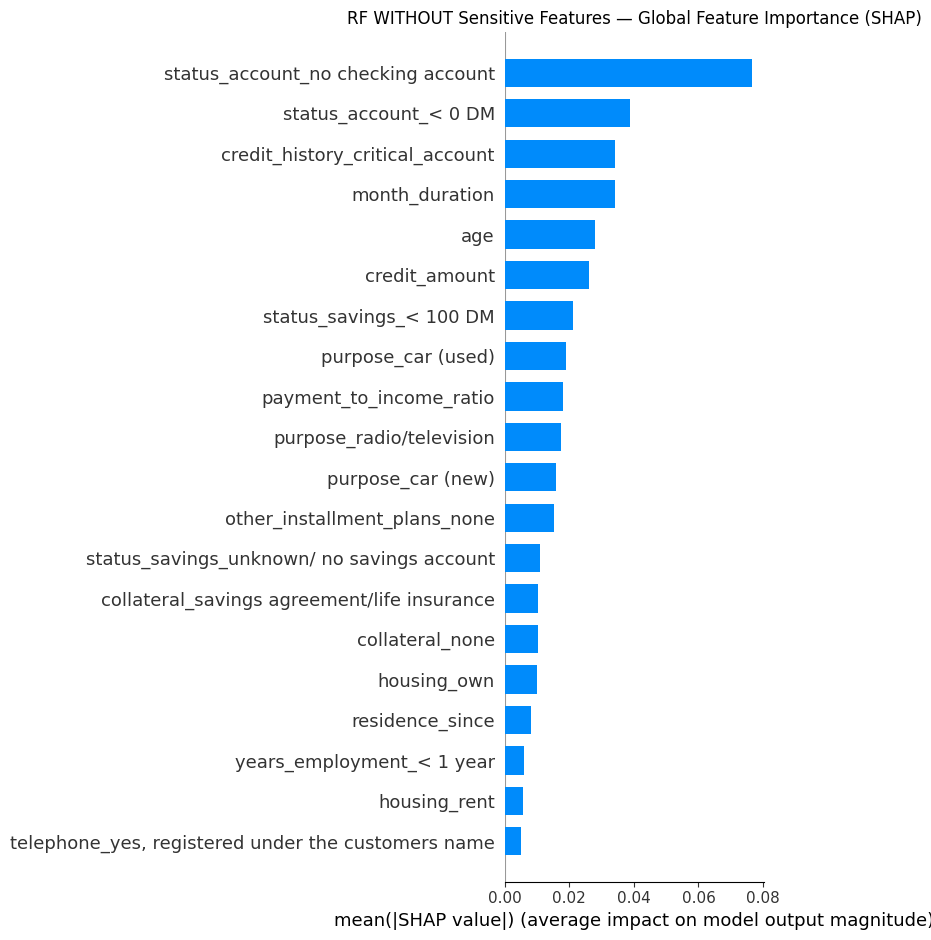

In [ ]:
# ============================================================
# Plot 1: Summary Plot (Global Feature Importance)
# ============================================================

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_without,    # SHAP values for good credit class
    X_test_without,
    plot_type="bar",        # bar chart version first (easier to read)
    max_display=20,         # top 20 features
    show=False
)
plt.title("RF WITHOUT Sensitive Features — Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

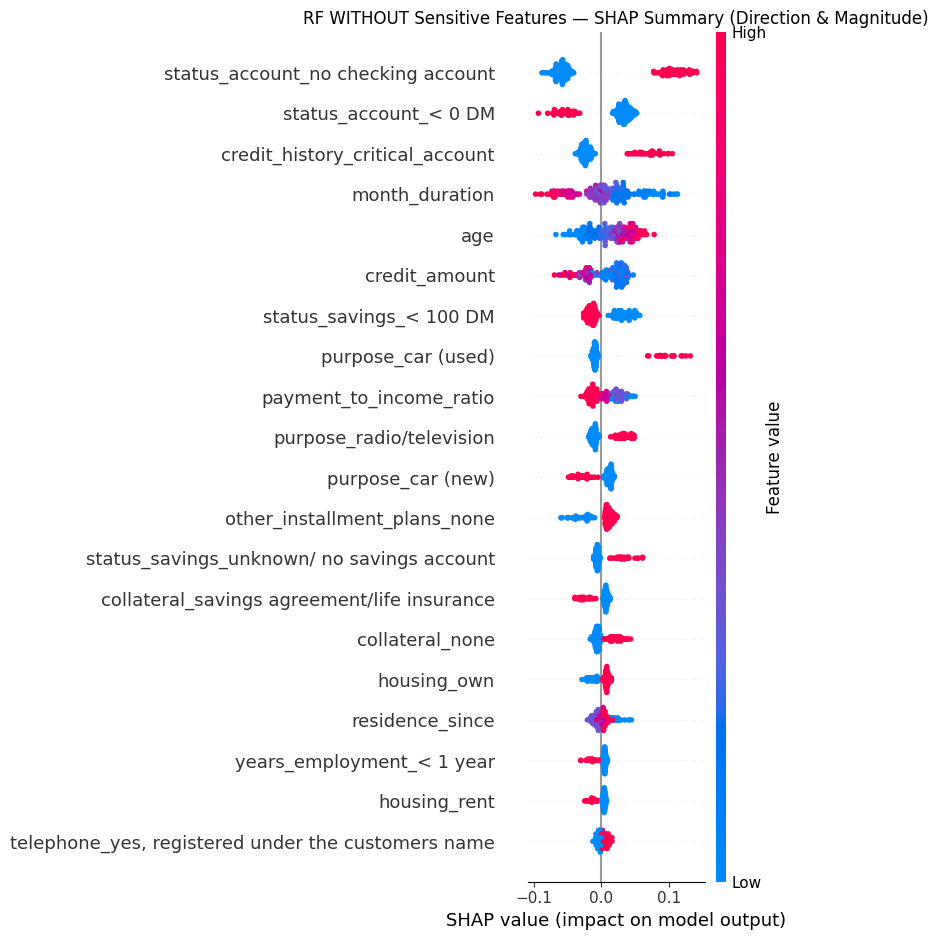

In [ ]:
# Summary plot dot version
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_without,
    X_test_without,
    max_display=20,
    show=False
)
plt.title("RF WITHOUT Sensitive Features — SHAP Summary (Direction & Magnitude)")
plt.tight_layout()
plt.show()

In [ ]:
# Feature importance table - WITHOUT SENSITIVE FEATURES
shap_importance_without = pd.DataFrame({
    'Feature': X_test_without.columns.tolist(),
    'Mean_SHAP': np.abs(shap_values_without).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

print("Top 20 features by mean absolute SHAP value:")
print(shap_importance_without.head(20))

Top 20 features by mean absolute SHAP value:
                                              Feature  Mean_SHAP
9                  status_account_no checking account   0.076534
7                               status_account_< 0 DM   0.038924
10                    credit_history_critical_account   0.034278
0                                      month_duration   0.034110
4                                                 age   0.027928
1                                       credit_amount   0.025979
24                            status_savings_< 100 DM   0.021314
15                                 purpose_car (used)   0.019031
2                             payment_to_income_ratio   0.018107
20                           purpose_radio/television   0.017588
14                                  purpose_car (new)   0.015994
36                       other_installment_plans_none   0.015166
26         status_savings_unknown/ no savings account   0.010896
35        collateral_savings agreement/life i

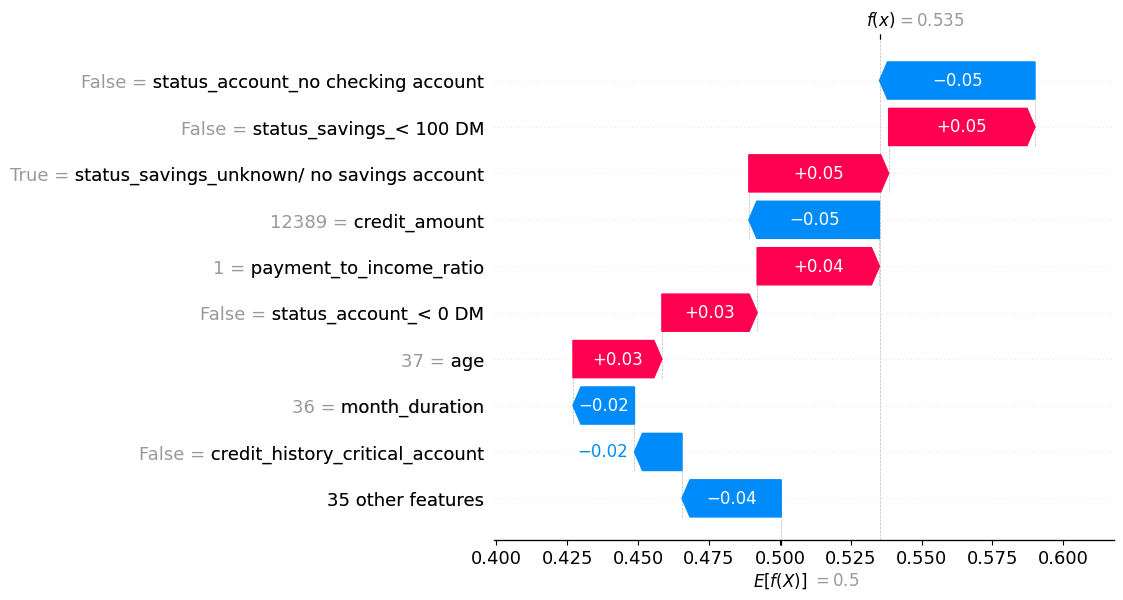

In [ ]:
# Waterfall plot fix
expected_val = explainer_without.expected_value
# expected_value is also now an array for binary classification
if isinstance(expected_val, np.ndarray):
    base_val = expected_val[1]  # good credit class
else:
    base_val = expected_val

false_negatives = np.where(
    (y_test_without.values == False) & (y_pred_without == True)
)[0]

if len(false_negatives) > 0:
    idx = false_negatives[0]
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_without[idx],
            base_values=base_val,
            data=X_test_without.iloc[idx],
            feature_names=X_test_without.columns.tolist()
        )
    )

## SHAP Comparison: With vs Without Sensitive Features

Removing status_and_sex and is_foreign_worker produced clean results:

1. status_and_sex_male:single disappeared from top 20 with no
   proxy replacement — importance redistributed to legitimate
   financial features rather than concentrating on a new
   demographic proxy

2. age moved from position 7 to position 5 — slight importance
   increase but justified by legitimate financial rationale
   (credit history length, employment stability)

3. Top financial predictors remained stable across both models:
   status_account, credit_history, month_duration, credit_amount,
   status_savings — confirming the model's core decision logic
   is financially grounded

4. Combined with the negligible performance difference
   (AUC: 0.775 → 0.770), this confirms that sensitive features
   were adding legal liability without adding predictive value.
   The fair model is both more ethical AND equally capable.

   Removing protected features → negligible performance drop + no proxy substitution + cleaner SHAP profile.

#XGBOOST - AN EXPERIMENT FOR PERFORMANCE IMPROVEMENT

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import re

# ============================================================
# XGBoost WITH Sensitive Features — Baseline
# ============================================================

# Note: XGBoost uses scale_pos_weight instead of class_weight='balanced'
# It's the ratio of negative to positive class samples
# 560 good (True) / 240 bad (False) in training set
scale_pos_weight = y_train_with.value_counts()[False] / y_train_with.value_counts()[True]
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

# Sanitize feature names for XGBoost
def sanitize_column_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[<>\[\]]', '_', col) # Replace <, >, [, ] with _
        new_col = re.sub(r'[^A-Za-z0-9_]+', '', new_col) # Remove any other non-alphanumeric chars
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_train_with_sanitized = sanitize_column_names(X_train_with.copy())
X_test_with_sanitized = sanitize_column_names(X_test_with.copy())

xgb_with = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    eval_metric='logloss',              # suppresses warning
    use_label_encoder=False,
    verbosity=0
)

xgb_with.fit(X_train_with_sanitized, y_train_with)

y_pred_xgb_with = xgb_with.predict(X_test_with_sanitized)
y_prob_xgb_with = xgb_with.predict_proba(X_test_with_sanitized)[:, 1]

print("\n=== XGBoost WITH Sensitive Features (Baseline) ===")
print(classification_report(y_test_with, y_pred_xgb_with))
print(f"AUC-ROC: {roc_auc_score(y_test_with, y_prob_xgb_with):.4f}")

scale_pos_weight: 0.4286

=== XGBoost WITH Sensitive Features (Baseline) ===
              precision    recall  f1-score   support

       False       0.52      0.55      0.54        60
        True       0.80      0.79      0.79       140

    accuracy                           0.71       200
   macro avg       0.66      0.67      0.67       200
weighted avg       0.72      0.71      0.72       200

AUC-ROC: 0.7527


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import re

# ============================================================
# XGBoost WITHOUT Sensitive Features — Baseline
# ============================================================

scale_pos_weight_fair = y_train_without.value_counts()[False] / y_train_without.value_counts()[True]

# Sanitize feature names for XGBoost (re-defining to ensure it's available in this cell)
def sanitize_column_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[<>\[\]]', '_', col) # Replace <, >, [, ] with _
        new_col = re.sub(r'[^A-Za-z0-9_]+', '', new_col) # Remove any other non-alphanumeric chars
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_train_without_sanitized = sanitize_column_names(X_train_without.copy())
X_test_without_sanitized = sanitize_column_names(X_test_without.copy())

xgb_without = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=scale_pos_weight_fair,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0
)

xgb_without.fit(X_train_without_sanitized, y_train_without)

y_pred_xgb_without = xgb_without.predict(X_test_without_sanitized)
y_prob_xgb_without = xgb_without.predict_proba(X_test_without_sanitized)[:, 1]

print("\n=== XGBoost WITHOUT Sensitive Features (Baseline) ===")
print(classification_report(y_test_without, y_pred_xgb_without))
print(f"AUC-ROC: {roc_auc_score(y_test_without, y_prob_xgb_without):.4f}")


=== XGBoost WITHOUT Sensitive Features (Baseline) ===
              precision    recall  f1-score   support

       False       0.55      0.53      0.54        60
        True       0.80      0.81      0.81       140

    accuracy                           0.73       200
   macro avg       0.68      0.67      0.68       200
weighted avg       0.73      0.73      0.73       200

AUC-ROC: 0.7562


XGBOOST TUNING WITH SENSITIVE FEATURES

In [ ]:
from sklearn.model_selection import GridSearchCV

params_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        verbosity=0
    ),
    param_grid=params_xgb,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='f1_macro'
)

grid_search_xgb.fit(X_train_with_sanitized, y_train_with)

print(f"Best params: {grid_search_xgb.best_params_}")
print(f"Best CV score: {grid_search_xgb.best_score_:.4f}")

xgb_best_with = grid_search_xgb.best_estimator_

y_pred_xgb_best = xgb_best_with.predict(X_test_with_sanitized)
y_prob_xgb_best = xgb_best_with.predict_proba(X_test_with_sanitized)[:, 1]

print("\n=== Tuned XGBoost WITH Sensitive Features ===")
print(classification_report(y_test_with, y_pred_xgb_best))
print(f"AUC-ROC: {roc_auc_score(y_test_with, y_prob_xgb_best):.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV score: 0.7126

=== Tuned XGBoost WITH Sensitive Features ===
              precision    recall  f1-score   support

       False       0.51      0.68      0.58        60
        True       0.84      0.71      0.77       140

    accuracy                           0.70       200
   macro avg       0.67      0.70      0.68       200
weighted avg       0.74      0.70      0.72       200

AUC-ROC: 0.7537


In [ ]:
#XGBOOST TUNED WITHOUT SENSITIVE FEATURES
from sklearn.model_selection import GridSearchCV

params_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        verbosity=0
    ),
    param_grid=params_xgb,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='f1_macro'
)

grid_search_xgb.fit(X_train_without_sanitized, y_train_without)

print(f"Best params: {grid_search_xgb.best_params_}")
print(f"Best CV score: {grid_search_xgb.best_score_:.4f}")

xgb_best_without = grid_search_xgb.best_estimator_

y_pred_xgb_best_without = xgb_best_without.predict(X_test_without_sanitized)
y_prob_xgb_best_without = xgb_best_without.predict_proba(X_test_without_sanitized)[:, 1]

print("\n=== Tuned XGBoost WITHOUT Sensitive Features ===")
print(classification_report(y_test_without, y_pred_xgb_best_without))
print(f"AUC-ROC: {roc_auc_score(y_test_without, y_prob_xgb_best_without):.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV score: 0.7159

=== Tuned XGBoost WITHOUT Sensitive Features ===
              precision    recall  f1-score   support

       False       0.47      0.62      0.53        60
        True       0.81      0.70      0.75       140

    accuracy                           0.68       200
   macro avg       0.64      0.66      0.64       200
weighted avg       0.71      0.68      0.69       200

AUC-ROC: 0.7462


#SHAP ANALYSIS ON XGBOOST

In [ ]:
import shap

# ============================================================
# SHAP Analysis - XGBoost WITH Sensitive Features
# ============================================================

explainer_xgb_with = shap.TreeExplainer(xgb_best_with)
shap_values_xgb_with = explainer_xgb_with.shap_values(X_test_with_sanitized)

print("XGBoost SHAP values type:", type(shap_values_xgb_with))
print("XGBoost SHAP values shape:", shap_values_xgb_with.shape)

XGBoost SHAP values type: <class 'numpy.ndarray'>
XGBoost SHAP values shape: (200, 48)


In [ ]:
# XGBoost returns 2D array directly (unlike RF which returned 3D)
# Shape should be (200, n_features) — no slicing needed
# But check first and handle accordingly:

if len(shap_values_xgb_with.shape) == 3:
    shap_vals_xgb_with = shap_values_xgb_with[:, :, 1]
else:
    shap_vals_xgb_with = shap_values_xgb_with  # already 2D

print("Extracted shape:", shap_vals_xgb_with.shape)

Extracted shape: (200, 48)


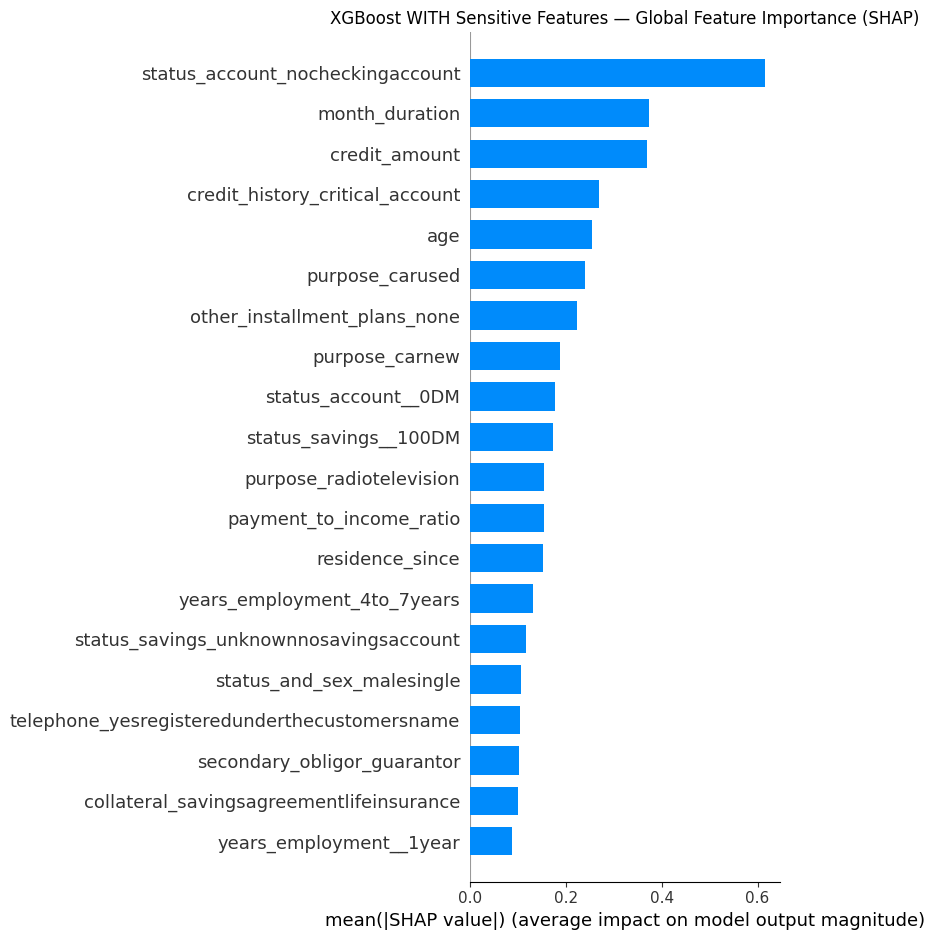

In [ ]:
# ============================================================
# Plot 1: Bar Summary — Global Feature Importance
# ============================================================

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals_xgb_with,
    X_test_with_sanitized,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("XGBoost WITH Sensitive Features — Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

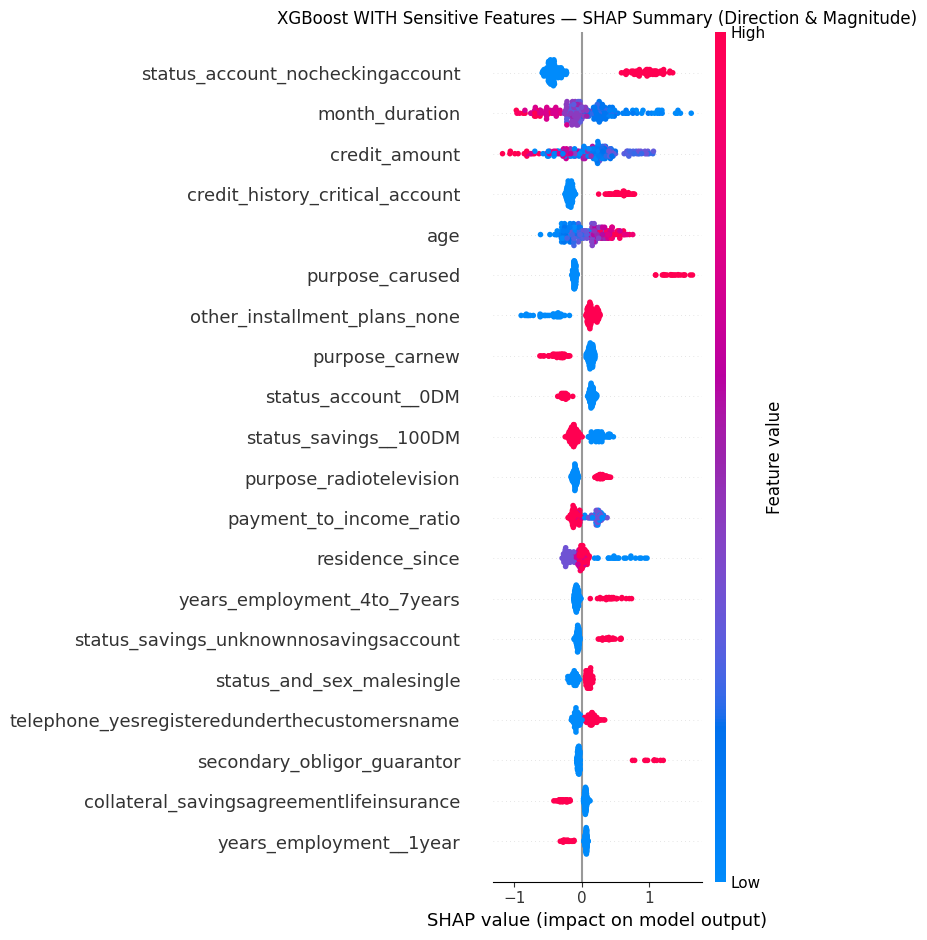

In [ ]:
# ============================================================
# Plot 2: Dot Summary — Direction & Magnitude
# ============================================================

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals_xgb_with,
    X_test_with_sanitized,
    max_display=20,
    show=False
)
plt.title("XGBoost WITH Sensitive Features — SHAP Summary (Direction & Magnitude)")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Feature Importance Table — check sensitive feature ranks
# ============================================================

shap_importance_xgb_with = pd.DataFrame({
    'Feature': X_test_with_sanitized.columns.tolist(),
    'Mean_SHAP': np.abs(shap_vals_xgb_with).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)

print("Top 20 features by mean absolute SHAP value:")
print(shap_importance_xgb_with.head(20))

# Check sensitive features specifically
sensitive_check = ['is_foreign_worker_yes',
                   'status_and_sex_male__single',    # sanitized name
                   'status_and_sex_male__marriedwidowed',
                   'status_and_sex_male__divorcedsepar']

print("\n=== Sensitive Feature Rankings ===")
for feat in sensitive_check:
    # fuzzy match since sanitization may have changed names slightly
    matches = shap_importance_xgb_with[
        shap_importance_xgb_with['Feature'].str.contains(
            feat.split('_')[3] if len(feat.split('_')) > 3 else feat,
            case=False,
            na=False
        )
    ]
    if not matches.empty:
        rank = matches.index[0] + 1
        val = matches['Mean_SHAP'].values[0]
        print(f"{matches['Feature'].values[0]}: rank {rank}, SHAP {val:.4f}")

Top 20 features by mean absolute SHAP value:
                                         Feature  Mean_SHAP
0               status_account_nocheckingaccount   0.616031
1                                 month_duration   0.373716
2                                  credit_amount   0.368583
3                credit_history_critical_account   0.269146
4                                            age   0.254224
5                                purpose_carused   0.239962
6                   other_installment_plans_none   0.222487
7                                 purpose_carnew   0.186821
8                            status_account__0DM   0.176724
9                          status_savings__100DM   0.173140
10                       purpose_radiotelevision   0.154447
11                       payment_to_income_ratio   0.153562
12                               residence_since   0.151178
13                   years_employment_4to_7years   0.131968
14        status_savings_unknownnosavingsaccount   0.11

#XGBOOST WITHOUT SENSITIVE FEATURES

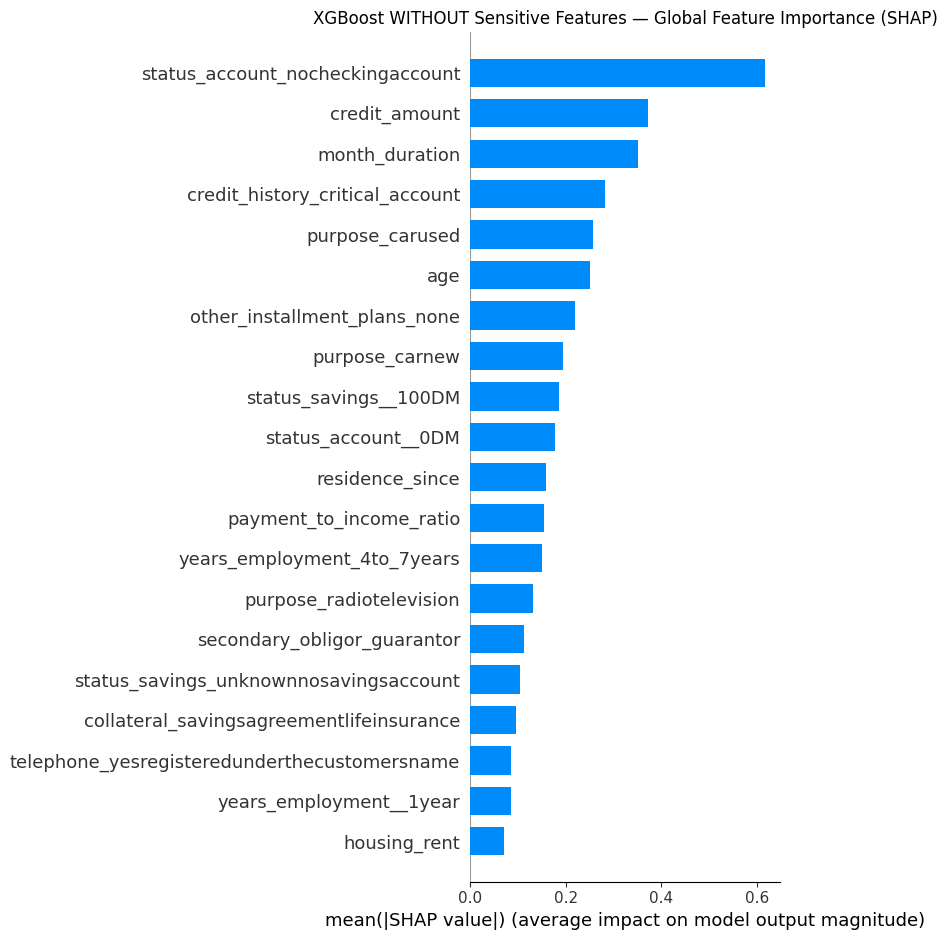

In [ ]:
# ============================================================
# SHAP Analysis - XGBoost WITHOUT Sensitive Features
# ============================================================

explainer_xgb_without = shap.TreeExplainer(xgb_best_without)
shap_values_xgb_without = explainer_xgb_without.shap_values(X_test_without_sanitized)

if len(shap_values_xgb_without.shape) == 3:
    shap_vals_xgb_without = shap_values_xgb_without[:, :, 1]
else:
    shap_vals_xgb_without = shap_values_xgb_without

# Bar summary
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals_xgb_without,
    X_test_without_sanitized,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("XGBoost WITHOUT Sensitive Features — Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Side by side SHAP importance comparison: WITH vs WITHOUT
# ============================================================

shap_importance_xgb_without = pd.DataFrame({
    'Feature': X_test_without_sanitized.columns.tolist(),
    'Mean_SHAP_without': np.abs(shap_vals_xgb_without).mean(axis=0)
}).sort_values('Mean_SHAP_without', ascending=False).reset_index(drop=True)

print("Top 20 features WITHOUT sensitive features:")
print(shap_importance_xgb_without.head(20))

Top 20 features WITHOUT sensitive features:
                                         Feature  Mean_SHAP_without
0               status_account_nocheckingaccount           0.617227
1                                  credit_amount           0.372609
2                                 month_duration           0.350947
3                credit_history_critical_account           0.281516
4                                purpose_carused           0.257100
5                                            age           0.250194
6                   other_installment_plans_none           0.220419
7                                 purpose_carnew           0.193697
8                          status_savings__100DM           0.184939
9                            status_account__0DM           0.177825
10                               residence_since           0.159486
11                       payment_to_income_ratio           0.154568
12                   years_employment_4to_7years           0.149417
13  

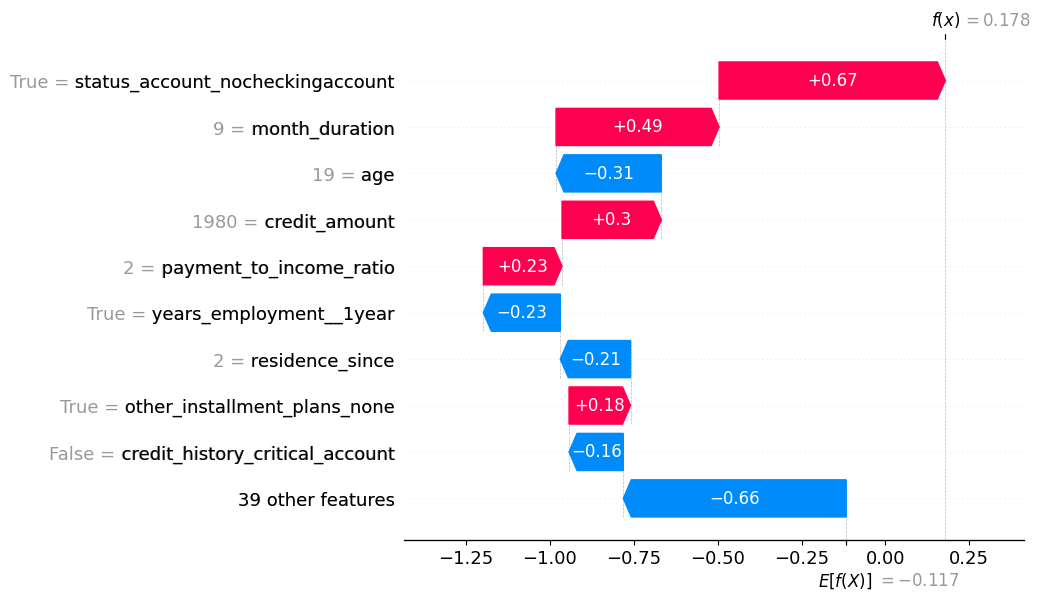

In [ ]:
# ============================================================
# Waterfall plot — one false negative from XGBoost
# ============================================================

false_negatives_xgb = np.where(
    (y_test_with.values == False) & (y_pred_xgb_best == True)
)[0]

if len(false_negatives_xgb) > 0:
    idx = false_negatives_xgb[0]

    expected_val_xgb = explainer_xgb_with.expected_value
    if isinstance(expected_val_xgb, np.ndarray):
        base_val_xgb = expected_val_xgb[0]
    else:
        base_val_xgb = expected_val_xgb

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals_xgb_with[idx],
            base_values=base_val_xgb,
            data=X_test_with_sanitized.iloc[idx],
            feature_names=X_test_with_sanitized.columns.tolist()
        )
    )

In [ ]:
# Complete model comparison
comparison = pd.DataFrame({
    'Model': [
        'LogReg Baseline',
        'LogReg SMOTE',
        'RF Baseline (with)',
        'RF Tuned (with)',
        'RF Tuned (without)',
        'XGB Baseline (with)',
        'XGB Tuned (with)',
        'XGB Tuned (without)'
    ],
    'Accuracy': [0.69, 0.68, 0.72, 0.70, 0.69, 0.71, 0.70, 0.68],
    'Bad_Recall': [0.43, 0.50, 0.35, 0.65, 0.65, 0.55, 0.68, 0.62],
    'Good_Recall': [0.79, 0.75, 0.88, 0.72, 0.70, 0.79, 0.71, 0.70],
    'AUC_ROC': [0.75, 0.74, 0.76, 0.775, 0.770, 0.753, 0.754, 0.746]
})

print(comparison.to_string(index=False))

              Model  Accuracy  Bad_Recall  Good_Recall  AUC_ROC
    LogReg Baseline      0.69        0.43         0.79    0.750
       LogReg SMOTE      0.68        0.50         0.75    0.740
 RF Baseline (with)      0.72        0.35         0.88    0.760
    RF Tuned (with)      0.70        0.65         0.72    0.775
 RF Tuned (without)      0.69        0.65         0.70    0.770
XGB Baseline (with)      0.71        0.55         0.79    0.753
   XGB Tuned (with)      0.70        0.68         0.71    0.754
XGB Tuned (without)      0.68        0.62         0.70    0.746


## Cross-Model SHAP Comparison Summary

### What stayed consistent across RF and XGBoost:

1. status_account_no_checking_account dominated both models as
   the single most important feature — legitimate financial signal
   confirmed by both architectures independently

2. is_foreign_worker absent from top 20 in both models —
   near-zero variance feature naturally discounted by tree-based
   splitting regardless of algorithm type

3. status_and_sex_male_single appeared in top 20 for both
   (RF position 15, XGBoost position 16) — genuine gender signal
   present but not dominant in either model

4. Removing sensitive features caused no proxy substitution
   in either model — importance redistributed to legitimate
   financial features cleanly

### What differed between RF and XGBoost:

1. Feature concentration: XGBoost relied more heavily on
   status_account (0.62 SHAP) vs RF's more distributed
   importance profile — XGBoost found a stronger single signal,
   RF spread importance more evenly

2. Sensitive feature impact on performance: RF showed negligible
   performance drop on sensitive feature removal, XGBoost showed
   small but nonzero drop (bad recall 0.68 → 0.62) — suggesting
   XGBoost extracted marginally more signal from gender features

3. Bad recall: XGBoost tuned (0.68) slightly outperformed RF
   tuned (0.65) — boosting's sequential error correction better
   targeted the minority class

Finding 1 — Performance: Tree-based models meaningfully improved bad credit recall over logistic regression (0.43 → 0.68), validating Blog 2's prediction that non-linear boundaries would help.
Finding 2 — Fairness: Removing sensitive features had negligible performance impact on RF and small impact on XGBoost — neither model needed them for accuracy, confirming they added legal liability with minimal predictive value.
Finding 3 — Interpretability evolution: SHAP revealed what logistic regression coefficients missed — is_foreign_worker's near-zero variance made it invisible to tree models while status_and_sex showed genuine signal in both. Post-hoc explanation tools can surface different bias patterns than architectural transparency alone.
